In [80]:
!pip install spacy
!python -m spacy download en_core_web_md

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import torch.optim as optim
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from torch.optim.lr_scheduler import StepLR
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import spacy
import re
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/cupyx/scipy/sparse/_base.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  import scipy.sparse as _sparse
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 22.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [24]:
nlp = spacy.load("en_core_web_md")  # This loads the pre-trained model

In [25]:
embedding_dim = 300
max_len = 30
batch_size = 64

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
# Load data (replace with your actual file paths)
train_path = '/content/cleaned_test.csv'
test_path = '/content/cleaned_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Re-index DataFrame to avoid index issues
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Tokenizer function to clean and split the tweets
def tokenize(text):
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+|[^a-zA-Z ]", "", str(text).lower())  # Clean text
    return text.split()


In [28]:
# Dataset class to handle data and convert text to embeddings
class TweetDataset(Dataset):
    def __init__(self, texts, labels, nlp, max_len=30):
        self.texts = texts
        self.labels = labels
        self.nlp = nlp
        self.max_len = max_len
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        try:
            # Access the text correctly from DataFrame
            text = self.texts.iloc[idx]
        except KeyError as e:
            print(f"Error accessing index {idx}: {e}")
            return None

        tokens = tokenize(text)

        # Initialize an empty list to store word embeddings
        vecs = []
        for token in tokens[:self.max_len]:
            word_vector = self.nlp(token).vector if self.nlp(token).has_vector else np.zeros(embedding_dim)
            vecs.append(word_vector)

        # Pad the sequences if they're shorter than max_len (with zero vectors)
        while len(vecs) < self.max_len:
            vecs.append(np.zeros(embedding_dim))  # Padding with zeros if necessary

        # Ensure all sequences have the same shape (max_len, embedding_dim)
        return torch.tensor(np.stack(vecs), dtype=torch.float32), torch.tensor(self.labels[idx])


In [38]:
# Set the percentage for subset of the training and test data
subset_percentage = 0.001  # 0.1% of the dataset

# Calculate subset sizes
subset_train_size = int(len(train_df) * subset_percentage)
test_subset_size = int(len(test_df) * subset_percentage)

# Create a subset of the training dataset by randomly sampling 0.1% of the data
subset_train_df = train_df.sample(n=subset_train_size, random_state=42)  # You can change the seed for different splits
subset_train_dataset = TweetDataset(subset_train_df['clean_tweet'], subset_train_df['sentiment'], nlp, max_len=max_len)

# Create DataLoader for the subset of the training data
subset_train_loader = DataLoader(subset_train_dataset, batch_size=64, shuffle=True, num_workers=0)

# Create a subset of the test dataset by randomly sampling 0.1% of the test data
test_subset_df = test_df.sample(n=test_subset_size, random_state=42)  # You can change the seed for different splits
test_subset_dataset = TweetDataset(test_subset_df['clean_tweet'], test_subset_df['sentiment'], nlp, max_len=max_len)

# Create DataLoader for the subset of the test data
test_subset_loader = DataLoader(test_subset_dataset, batch_size=64, shuffle=False, num_workers=0)

# Optional: Verify that the subsets for both train and test data are created properly
print(f"Subset Train DataLoader: {len(subset_train_loader.dataset)} samples")
print(f"Subset Test DataLoader: {len(test_subset_loader.dataset)} samples")


Subset Train DataLoader: 90 samples
Subset Test DataLoader: 90 samples


In [39]:
# Positional Encoding class
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pos_enc = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pos_enc[:, 0::2] = torch.sin(position * div_term)
        pos_enc[:, 1::2] = torch.cos(position * div_term)
        self.pos_enc = pos_enc.unsqueeze(0)

    def forward(self, x):
        return x + self.pos_enc[:, :x.size(1)].to(x.device)

# Transformer model class
class TransformerClassifier(nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers, max_len, num_classes):
        super().__init__()
        self.pos_enc = PositionalEncoding(embed_dim, max_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(embed_dim * max_len, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.pos_enc(x)
        x = self.transformer(x)
        return self.classifier(x)


In [40]:
# Hyperparameter setup
embed_dim = 300   # Example embedding dimension
num_heads = 4     # Example number of attention heads
num_layers = 2    # Example number of layers

# Ensure embed_dim is divisible by num_heads
assert embed_dim % num_heads == 0, f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"

# Create the Transformer model
model = TransformerClassifier(embed_dim=embed_dim, num_heads=num_heads, num_layers=num_layers, max_len=30, num_classes=len(np.unique(train_df['sentiment']))).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [106]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

def train(model, subset_train_loader, optimizer, criterion, epochs=15):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in subset_train_loader:
            X_batch, y_batch = X_batch.to(device).float(), y_batch.to(device).long()  # Convert data types
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(subset_train_loader)}, Accuracy: {correct/total}")

train(model, subset_train_loader, optimizer, criterion, epochs=15)


Epoch 1/15, Loss: 0.7932501137256622, Accuracy: 0.6888888888888889
Epoch 2/15, Loss: 0.6495669484138489, Accuracy: 0.7
Epoch 3/15, Loss: 0.6864984631538391, Accuracy: 0.7444444444444445
Epoch 4/15, Loss: 0.5632887184619904, Accuracy: 0.7222222222222222
Epoch 5/15, Loss: 0.5517809987068176, Accuracy: 0.7111111111111111
Epoch 6/15, Loss: 0.5200380086898804, Accuracy: 0.7222222222222222
Epoch 7/15, Loss: 0.5172390937805176, Accuracy: 0.7555555555555555
Epoch 8/15, Loss: 0.44439101219177246, Accuracy: 0.8111111111111111
Epoch 9/15, Loss: 0.4632532596588135, Accuracy: 0.7555555555555555
Epoch 10/15, Loss: 0.4067821651697159, Accuracy: 0.7666666666666667
Epoch 11/15, Loss: 0.4094008207321167, Accuracy: 0.8666666666666667
Epoch 12/15, Loss: 0.36046698689460754, Accuracy: 0.8777777777777778
Epoch 13/15, Loss: 0.333734929561615, Accuracy: 0.8888888888888888
Epoch 14/15, Loss: 0.3345334380865097, Accuracy: 0.8777777777777778
Epoch 15/15, Loss: 0.2924312651157379, Accuracy: 0.9444444444444444


In [111]:
def evaluate(model, test_subset_loader):
    model.eval()
    true_labels = []
    predictions = []

    with torch.no_grad():
        for X_batch, y_batch in test_subset_loader:
            X_batch, y_batch = X_batch.to(device).float(), y_batch.to(device).long()  # Convert data types
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)

            true_labels.extend(y_batch.cpu().numpy())
            predictions.extend(predicted.cpu().numpy())
    return true_labels, predictions

true_labels, predictions = evaluate(model, test_subset_loader)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.94      0.88      0.91        17
           2       0.97      0.98      0.98        62

    accuracy                           0.97        90
   macro avg       0.97      0.96      0.96        90
weighted avg       0.97      0.97      0.97        90



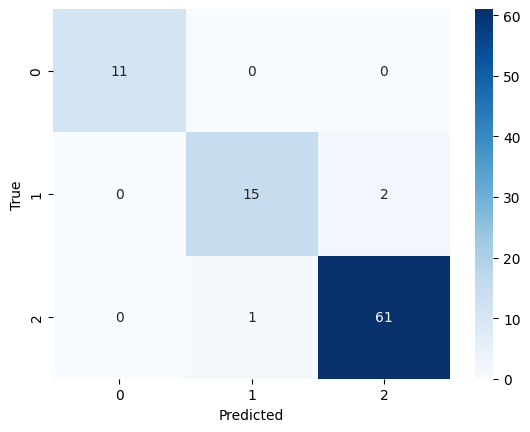

In [112]:
from sklearn.metrics import classification_report # Import classification_report

# Classification report
print(classification_report(true_labels, predictions))
# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()